In [74]:
import pandas as pd

#Dataframe creation
df = pd.read_csv("house_prices.csv")    

#How many rows and columns?
df.shape    

(187531, 21)

In [75]:
#Display the first 5 rows of the dataframe to get a glimpse of the data
df.head() 

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [76]:
#Dataframe information: data types, non-null values, memory usage
df.info()   

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [77]:
#Get a summary of the dataframe
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [78]:
#Check for % missing values in the dataframe
df.isna().mean().sort_values(ascending=False) 

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

## 2.1 Load & Inspect — Summary

- The dataset contains **187,531 rows** and **21 columns**.
- Only `Index`, `Price (in rupees)`, `Dimensions`, and `Plot Area` are numeric (float64/int64); 
  the remaining 17 columns are stored as text, since several (e.g. `Bathroom`, `Balcony`, 
  `Car Parking`) mix numbers with words like "2 Open".
- `Plot Area` and `Dimensions` are 100% missing and will be dropped.
- The most missing columns are `Society` (58%), `Super Area` (57%), `Car Parking` (55%), 
  `overlooking` (43%), and `Carpet Area` (43%).
- `Price (in rupees)` looks pre-parsed but its values don't match the `Amount(in rupees)` 
  text prices, so the actual price will be derived from `Amount(in rupees)` instead.


In [79]:
# Define a function to parse amount strings
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

In [80]:
# Clean the "Amount(in rupees)" column and create a new column "price_clean"
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

In [81]:
df.shape 

(177847, 22)

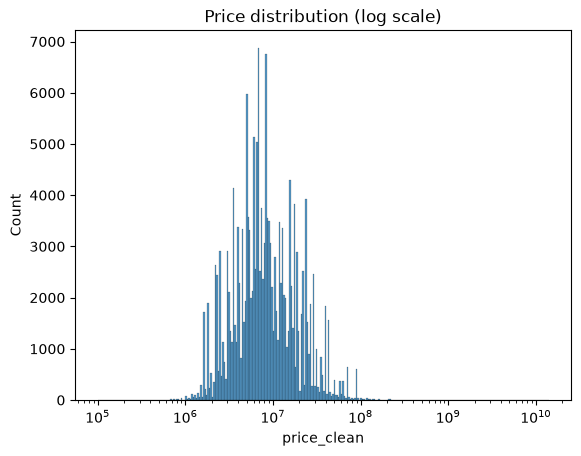

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of the "price_clean" column with a log scale
sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

**Price distribution:** The raw price is heavily right-skewed (a few very 
expensive properties dominate). After applying a log scale, the distribution becomes 
roughly bell-shaped, which confirms that training on `log1p(price)` later should improve 
model performance.

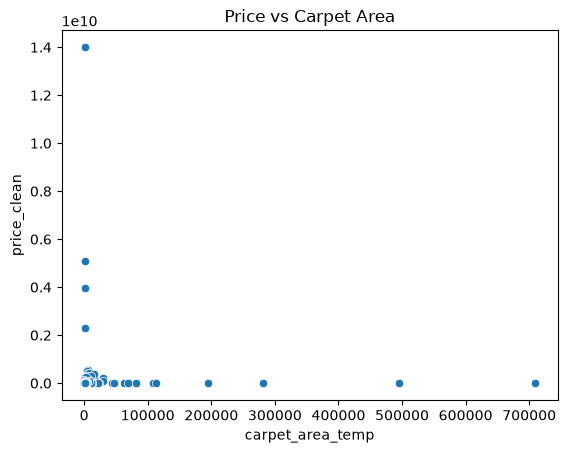

In [83]:
# Grouping by "location" and calculating the average price for each location
df["carpet_area_temp"] = df["Carpet Area"].str.extract(r'(\d+\.?\d*)').astype(float)
# Scatter plot of "Carpet Area" vs "price_clean"
sns.scatterplot(x=df["carpet_area_temp"], y=df["price_clean"])
plt.title("Price vs Carpet Area")
plt.show()

In [84]:
# Describe the cleaned price column
df["price_clean"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

In [85]:
# Remove outliers based on the 1st and 99th percentiles
lower = df["price_clean"].quantile(0.01)
upper = df["price_clean"].quantile(0.99)

df_eda = df[(df["price_clean"] >= lower) & (df["price_clean"] <= upper)]
print(df.shape, "->", df_eda.shape)

(177847, 23) -> (175484, 23)


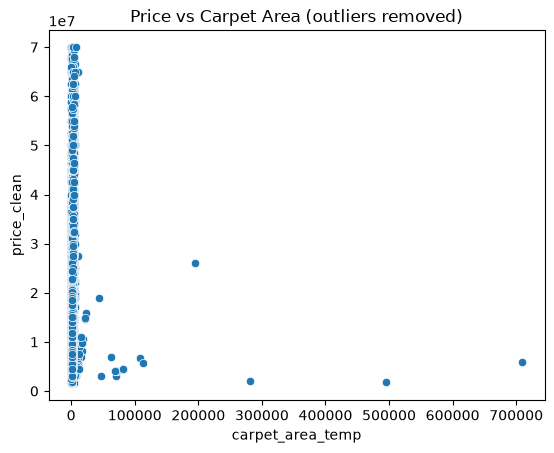

In [86]:
sns.scatterplot(x=df_eda["carpet_area_temp"], y=df_eda["price_clean"])
plt.title("Price vs Carpet Area (outliers removed)")
plt.show()

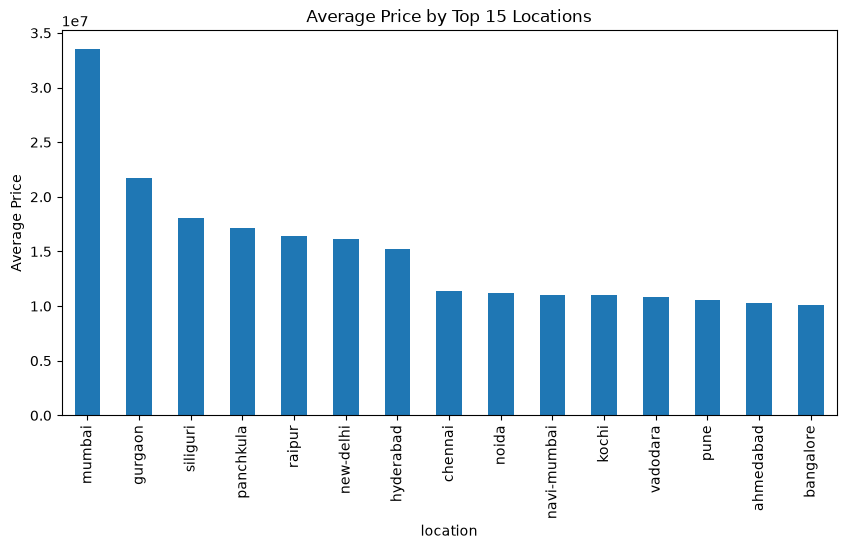

In [87]:
# Grouping by "location" and calculating the average price for each location
top_locations = df.groupby("location")["price_clean"].mean().sort_values(ascending=False).head(15)
top_locations.plot(kind="bar", figsize=(10,5))
plt.title("Average Price by Top 15 Locations")
plt.ylabel("Average Price")
plt.show()

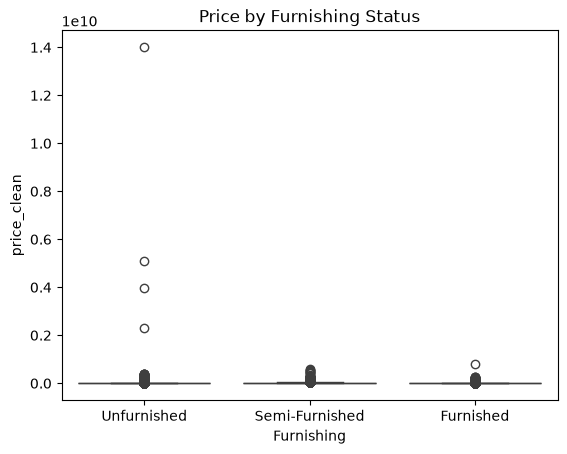

In [88]:
# Boxplot of "Furnishing" vs "price_clean"
sns.boxplot(x=df["Furnishing"], y=df["price_clean"])
plt.title("Price by Furnishing Status")
plt.show()

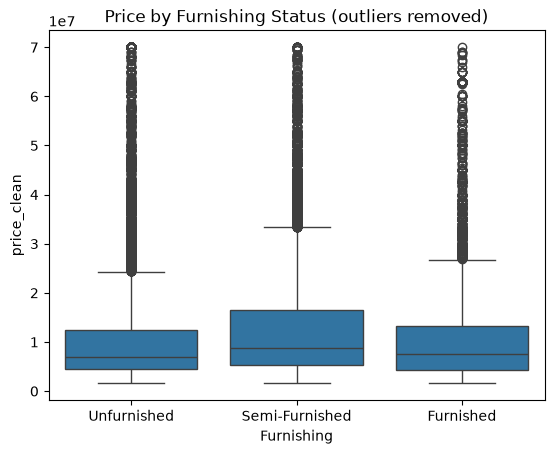

In [89]:
sns.boxplot(x=df_eda["Furnishing"], y=df_eda["price_clean"])
plt.title("Price by Furnishing Status (outliers removed)")
plt.show()

In [90]:
df_eda["carpet_area_temp"].describe()

count    100101.000000
mean       1202.266741
std        3122.994931
min           1.000000
25%         777.000000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_temp, dtype: float64

In [91]:
# Remove outliers based on the 1st and 99th percentiles for carpet area
area_lower = df_eda["carpet_area_temp"].quantile(0.01)
area_upper = df_eda["carpet_area_temp"].quantile(0.99)

df_eda2 = df_eda[(df_eda["carpet_area_temp"] >= area_lower) & (df_eda["carpet_area_temp"] <= area_upper)]
print(df_eda.shape, "->", df_eda2.shape) 

(175484, 23) -> (99441, 23)


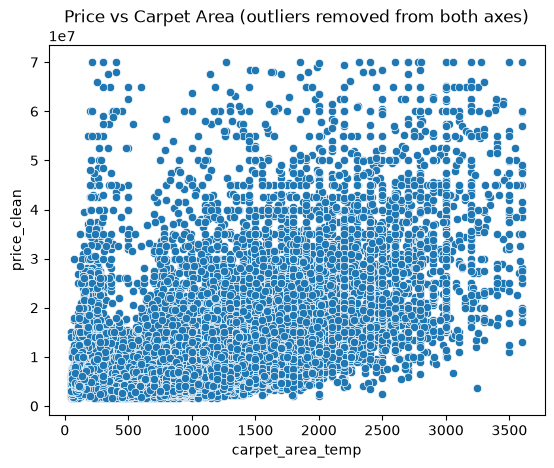

In [92]:
sns.scatterplot(x=df_eda2["carpet_area_temp"], y=df_eda2["price_clean"])
plt.title("Price vs Carpet Area (outliers removed from both axes)")
plt.show()

## 2.2 EDA — Summary

- **Price distribution:** heavily right-skewed; a log scale reveals a roughly bell-shaped 
  distribution, supporting the use of `log1p(price)` when training later.
- **Price vs Carpet Area:** after removing extreme outliers from both variables, the 
  relationship is a clear cone/fan shape — price generally rises with area, but with 
  significant spread, meaning area alone doesn't fully explain price.
- **Top 15 locations by average price:** Mumbai leads by a wide margin, followed by Gurgaon 
  and Siliguri — consistent with known real-estate market patterns in India.
- **Price by furnishing status:** Semi-Furnished properties show a slightly higher median 
  price than Unfurnished or Furnished ones.

In [93]:

# Show unique values for Carpet Area (first 20)
df["Carpet Area"].dropna().unique()[:20]

<StringArray>
[ '500 sqft',  '473 sqft',  '779 sqft',  '530 sqft',  '635 sqft',  '550 sqft',
  '900 sqft',  '950 sqft', '1820 sqft',  '675 sqft',  '647 sqft',  '600 sqft',
  '430 sqft',  '665 sqft',  '557 sqft',  '870 sqft',  '288 sqft',  '925 sqft',
  '434 sqft', '1350 sqft']
Length: 20, dtype: str

In [94]:
# Show unique values for Super Area (first 20)
df["Super Area"].dropna().unique()[:20]

<StringArray>
[ '680 sqft',  '575 sqft',  '600 sqft', '1165 sqft',  '844 sqft',  '650 sqft',
  '540 sqft',  '520 sqft',  '580 sqft',  '630 sqft',  '690 sqft',  '750 sqft',
  '482 sqft', '1100 sqft',  '770 sqft',  '530 sqft',  '481 sqft',  '381 sqft',
  '590 sqft',  '860 sqft']
Length: 20, dtype: str

In [95]:
# Parse area values into square feet
df["Carpet Area"].dropna().str.extract(r'[\d.]+\s*([a-zA-Z]+)')[0].value_counts()

0
sqft      95986
sqyrd      4658
sqm         870
acre          2
marla         2
kanal         2
ground        1
bigha         1
Name: count, dtype: int64

In [96]:
# Show unit distribution for Super Area
df["Super Area"].dropna().str.extract(r'[\d.]+\s*([a-zA-Z]+)')[0].value_counts()

0
sqft        71901
sqyrd        3463
sqm           854
marla           8
ground          3
kanal           3
aankadam        1
acre            1
cent            1
Name: count, dtype: int64

In [97]:
# Parse area values into square feet
import re

def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    
    match = re.search(r'([\d.]+)', x)
    if not match:
        return None
    value = float(match.group(1))
    
    if "sqft" in x:
        return value
    if "sqyrd" in x:
        return value * 9        
    if "sqm" in x:
        return value * 10.764   
    
    return None

In [98]:
# Parse area values into square feet
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

In [99]:
# Show unit distribution for Super Area
print("Carpet Area:", df["carpet_area_sqft"].notna().sum(), "/", df["Carpet Area"].notna().sum())
print("Super Area:", df["super_area_sqft"].notna().sum(), "/", df["Super Area"].notna().sum())

Carpet Area: 101514 / 101522
Super Area: 76218 / 76235


**Area unit handling:** Both `Carpet Area` and `Super Area` contained multiple units 
beyond sqft/sqm — including sqyrd, acre, marla, kanal, ground, and bigha. Since the 
latter group are regionally inconsistent (their real-world size varies by Indian state) 
and represent a negligible fraction of rows (1-8 rows each), they were converted to 
missing values rather than guessed, to avoid introducing unreliable data.

In [100]:
# Combine the cleaned area values
df["area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
print("Combined area_sqft:", df["area_sqft"].notna().sum(), "/", len(df))

Combined area_sqft: 177732 / 177847


In [101]:
df["area_sqft"].notna().sum()

np.int64(177732)

In [102]:
# Show unique values in the "Floor" column
df["Floor"].dropna().unique()[:20]

<StringArray>
[   '10 out of 11',     '3 out of 22',    '10 out of 29',      '1 out of 3',
    '20 out of 42',      '2 out of 7',      '4 out of 5', 'Ground out of 7',
 'Ground out of 2',     '3 out of 27',     '6 out of 20',    '16 out of 24',
     '8 out of 20',    '18 out of 27',      '2 out of 3',    '10 out of 16',
      '5 out of 7',    '20 out of 28',      '3 out of 3',      '3 out of 7']
Length: 20, dtype: str

In [103]:
# Show value counts for the first part of the "Floor" column after splitting
df["Floor"].dropna().str.split(" out of").str[0].value_counts()

Floor
2                 31061
1                 30946
3                 24924
4                 17225
5                 11849
Ground            10584
6                  6864
7                  6648
8                  5193
10                 4979
12                 3794
11                 3017
9                  2948
15                 1629
14                 1604
18                 1199
16                 1173
13                 1020
17                  980
19                  884
32                  721
20                  337
21                  257
Upper Basement      210
23                  140
Lower Basement      125
22                  100
25                   92
24                   79
26                   63
28                   52
30                   47
27                   37
29                   22
33                   12
40                   11
35                   11
31                   11
34                   10
38                    5
42                    4
60        

In [104]:
# Identify non-numeric values in the "Floor" column
non_numeric = df["Floor"].dropna().str.split(" out of").str[0].str.strip()
non_numeric[~non_numeric.str.match(r'^\d+$')].value_counts()

Floor
Ground            10584
Upper Basement      210
Lower Basement      125
Name: count, dtype: int64

In [105]:
# Parse the "Floor" column and convert it to a numeric value
def parse_floor(x):
    if not isinstance(x, str):
        return None
    floor_part = x.split(" out of")[0].strip().lower()
    
    if floor_part == "ground":
        return 0
    if floor_part == "upper basement":
        return -1
    if floor_part == "lower basement":
        return -2
    
    try:
        return int(floor_part)
    except ValueError:
        return None

In [106]:
# Convert the "Floor" column to a numeric value
df["floor_num"] = df["Floor"].apply(parse_floor)
print("Floor:", df["floor_num"].notna().sum(), "/", df["Floor"].notna().sum())

Floor: 170898 / 170898


**Floor parsing:** The `Floor` column followed an "X out of Y" format, but contained 
three non-numeric floor labels: `Ground` (10,584 rows), `Upper Basement` (210 rows), 
and `Lower Basement` (125 rows). These were mapped to 0, -1, and -2 respectively, 
following real-world building order (basement levels below ground, then ascending 
floor numbers). This achieved 100% parsing coverage.

In [107]:
# Show unique values in the "Bathroom" column
df["Bathroom"].dropna().unique()[:20]

<StringArray>
['1', '2', '3', '4', '6', '5', '9', '8', '> 10', '7', '10']
Length: 11, dtype: str

In [108]:
# Show values in the "Bathroom" column that are not numeric
df["Bathroom"].dropna()[~df["Bathroom"].dropna().str.match(r'^\d+$')].value_counts()

Bathroom
> 10    29
Name: count, dtype: int64

In [109]:
# Show unique values in the "Balcony" column
df["Balcony"].dropna().unique()[:20]

<StringArray>
['2', '1', '3', '4', '6', '5', '7', '> 10', '10', '8', '9']
Length: 11, dtype: str

In [110]:
# Show values in the "Balcony" column that are not numeric
df["Balcony"].dropna()[~df["Balcony"].dropna().str.match(r'^\d+$')].value_counts()

Balcony
> 10    16
Name: count, dtype: int64

In [111]:
# Show unique values in the "Car Parking" column
df["Car Parking"].dropna().unique()[:20]

<StringArray>
[     '1 Open',   '1 Covered',   '2 Covered',  '66 Covered', '701 Covered',
   '3 Covered',  '1 Covered,',     '35 Open',      '4 Open', '323 Covered',
  '11 Covered',    '103 Open', '203 Covered',      '2 Open', '180 Covered',
     '14 Open',     '50 Open',  '10 Covered',     '15 Open',      '5 Open']
Length: 20, dtype: str

In [112]:
# Show the count of each unique value in the "Car Parking" column after extracting non-numeric parts
df["Car Parking"].dropna().str.extract(r'\d+\.?\d*\s*(\D*)')[0].value_counts()

0
Covered     49556
Covered,    21075
Open        11304
Name: count, dtype: int64

In [113]:
# Define a function to parse count values
def parse_count(x):
    if not isinstance(x, str):
        return None
    x = x.strip()
    if x == "> 10":
        return 11        
    try:
        return int(x)
    except ValueError:
        return None

In [114]:
# Apply the parsing function to create new columns with numeric values
df["bathroom_num"] = df["Bathroom"].apply(parse_count)
df["balcony_num"] = df["Balcony"].apply(parse_count)

In [115]:
# Define a function to parse car parking values
def parse_car_parking(x):
    if not isinstance(x, str):
        return None
    match = re.search(r'(\d+)', x)
    if not match:
        return None
    return int(match.group(1))

In [116]:
# Apply the parsing function to create a new column with numeric values for car parking
df["car_parking_num"] = df["Car Parking"].apply(parse_car_parking)

In [117]:
# Show the count of each unique value in the "Car Parking" column after extracting non-numeric parts
print("Bathroom:", df["bathroom_num"].notna().sum(), "/", df["Bathroom"].notna().sum())
print("Balcony:", df["balcony_num"].notna().sum(), "/", df["Balcony"].notna().sum())
print("Car Parking:", df["car_parking_num"].notna().sum(), "/", df["Car Parking"].notna().sum())

Bathroom: 177087 / 177087
Balcony: 130688 / 130688
Car Parking: 81935 / 81935


In [118]:
# Fill missing values with median for bathroom and balcony counts
df["bathroom_num"] = df["bathroom_num"].fillna(df["bathroom_num"].median())
df["balcony_num"] = df["balcony_num"].fillna(df["balcony_num"].median())
# Fill missing values with 0 for car parking count
df["car_parking_num"] = df["car_parking_num"].fillna(0)

In [119]:
# Check for missing values in the newly created numeric columns
print(df[["bathroom_num", "balcony_num", "car_parking_num"]].isna().sum())

bathroom_num       0
balcony_num        0
car_parking_num    0
dtype: int64


**Missing value imputation:** `bathroom_num` and `balcony_num` were imputed with the 
median, since nearly all listed properties have at least one bathroom/balcony, making 
median a realistic "typical" value. `car_parking_num` was imputed with 0, since a missing 
value most likely indicates no parking was listed (rather than an unreported positive count).

In [120]:
# Show the count of unique locations and societies
print("Unique locations:", df["location"].nunique())
print("Unique societies:", df["Society"].nunique())

Unique locations: 81
Unique societies: 10068


In [121]:
# Show the top 20 most common locations
df["location"].value_counts().head(20)

location
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
visakhapatnam     1729
mohali            1479
zirakpur          1478
chandigarh        1402
noida             1247
Name: count, dtype: int64

In [122]:
# Group less common societies into an "other" category
top_societies = df["Society"].value_counts().head(50).index
df["society_grouped"] = df["Society"].where(df["Society"].isin(top_societies), "other")

In [123]:
# Show the top 10 most common grouped societies
df["society_grouped"].value_counts().head(10)

society_grouped
other                         141671
Hamdam Apartment                1648
Malibu Town                     1158
Shree Vardhman Victoria         1154
DLF Skycourt                    1153
Nebula Tower                     982
Harmony Apartment                828
Defence Officers Apartment       827
East of Kailash                  826
Sarve Satyam Apartment           825
Name: count, dtype: int64

**Society grouping:** `Society` had 10,068 unique values with 58% missing. The top 50 
societies (by frequency) were kept as individual categories, and everything else — 
including missing values and rare societies — was grouped into "other". This merges 
"unknown" with "known-but-rare" into a single category, which is a reasonable 
simplification since both carry limited predictive signal individually.

In [124]:
# Drop unnecessary columns
columns_to_drop = ["Index", "Title", "Description", "Dimensions", "Plot Area",
                    "Carpet Area", "Super Area", "carpet_area_sqft", "super_area_sqft",
                    "carpet_area_temp",
                    "Floor", "Bathroom", "Balcony", "Car Parking", "Society",
                    "Amount(in rupees)", "Price (in rupees)"]

df_clean = df.drop(columns=columns_to_drop)
df_clean.columns.tolist()

['location',
 'Status',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Ownership',
 'price_clean',
 'area_sqft',
 'floor_num',
 'bathroom_num',
 'balcony_num',
 'car_parking_num',
 'society_grouped']

In [125]:
# Filter out rows with non-positive area values and calculate price per square foot
df_clean = df_clean[df_clean["area_sqft"] > 0]
df_clean["price_per_sqft"] = df_clean["price_clean"] / df_clean["area_sqft"]

In [126]:
# Show descriptive statistics for the "price_per_sqft" column
df_clean["price_per_sqft"].describe()

count    1.777320e+05
mean     1.242286e+04
std      3.380015e+05
min      3.830877e+00
25%      4.700855e+03
50%      6.666667e+03
75%      1.034483e+04
max      5.454545e+07
Name: price_per_sqft, dtype: float64

In [127]:
# Calculate the lower and upper bounds for price per square foot based on the 1st and 99th percentiles
lower = df_clean["price_per_sqft"].quantile(0.01)
upper = df_clean["price_per_sqft"].quantile(0.99)
print("Lower bound:", lower, "| Upper bound:", upper)

Lower bound: 2265.621212121212 | Upper bound: 33882.35294117647


In [128]:
# Filter the dataframe to remove outliers based on the calculated bounds
before = df_clean.shape[0]
df_clean = df_clean[(df_clean["price_per_sqft"] >= lower) & (df_clean["price_per_sqft"] <= upper)]
after = df_clean.shape[0]
print(f"Before: {before} -> After: {after} (removed {before - after} rows)")

Before: 177732 -> After: 174237 (removed 3495 rows)


**Outlier removal (price-per-sqft):** The mean price-per-sqft (₹12,422) was nearly 
double the median (₹6,666), and the maximum value (₹54.5M/sqft) was clearly unrealistic — 
strong evidence of extreme outliers. Rows outside the 1st-99th percentile range 
(₹2,266 - ₹33,882 per sqft) were removed, dropping 3,495 rows (~2%) and leaving 174,237 
clean rows for training.

In [129]:
# Drop the "price_per_sqft" column as it is no longer needed
df_clean = df_clean.drop(columns=["price_per_sqft"])
df_clean.shape

(174237, 14)

In [130]:
# Prepare the feature matrix and target variable
numeric_features = ["area_sqft", "floor_num", "bathroom_num", "balcony_num", "car_parking_num"]
categorical_features = ["location", "Status", "Transaction", "Furnishing", "facing", "overlooking", "Ownership", "society_grouped"]

X = df_clean[numeric_features + categorical_features]
y = df_clean["price_clean"]

print(X.shape, y.shape)

(174237, 13) (174237,)


In [131]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (139389, 13) | Test: (34848, 13)


In [132]:
# Prepare the preprocessor for feature engineering
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

In [133]:
# Train the Linear Regression model
from sklearn.linear_model import LinearRegression

model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

model_lr.fit(X_train, y_train)
print("Linear Regression trained ✅")

Linear Regression trained ✅


In [134]:
# Train the Random Forest model
from sklearn.ensemble import RandomForestRegressor

model_rf = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42))
])

model_rf.fit(X_train, y_train)
print("Random Forest trained ✅")

Random Forest trained ✅


In [135]:
# Evaluation function for regression models
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(model, name, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}:")
    print(f"  MAE : {mae:,.0f}")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  R²  : {r2:.4f}")
    return pred

In [136]:
# Evaluate the models
pred_lr = evaluate(model_lr, "Linear Regression", X_test, y_test)
pred_rf = evaluate(model_rf, "Random Forest", X_test, y_test)

Linear Regression:
  MAE : 3,117,838
  RMSE: 5,738,436
  R²  : 0.7666
Random Forest:
  MAE : 892,103
  RMSE: 2,981,783
  R²  : 0.9370


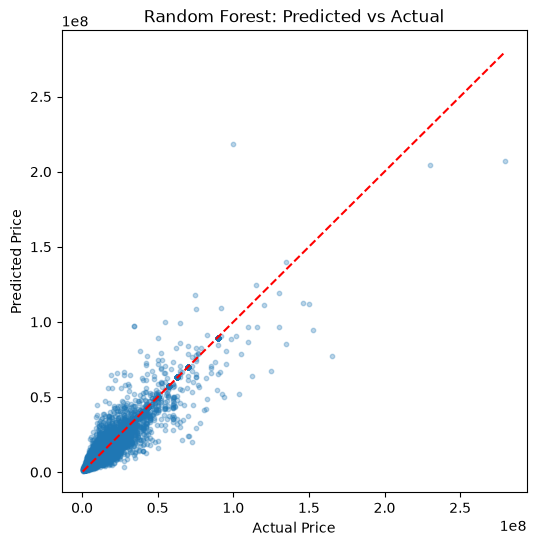

In [137]:
# Visualize the results for Random Forest
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

In [138]:
# Compare the performance of the models
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mean_absolute_error(y_test, pred_lr), mean_absolute_error(y_test, pred_rf)],
    "RMSE": [root_mean_squared_error(y_test, pred_lr), root_mean_squared_error(y_test, pred_rf)],
    "R2": [r2_score(y_test, pred_lr), r2_score(y_test, pred_rf)]
})
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,3.117838e+06,5.738436e+06,0.766626
1,Random Forest,8.921026e+05,2.981783e+06,0.936989


## 2.5 Model Comparison & Conclusion

| Model              | MAE       | RMSE      | R²     |
|--------------------|-----------|-----------|--------|
| Linear Regression  | 3,117,838 | 5,738,436 | 0.7666 |
| Random Forest      | 892,103   | 2,981,783 | 0.9370 |

**Random Forest was selected as the final model.** It outperformed Linear Regression 
across all three metrics — reducing MAE by roughly 3.5x and explaining 93.7% of price 
variance (vs. 76.7% for Linear Regression). This gap suggests the relationship between 
property features (area, location, furnishing, etc.) and price is highly non-linear, 
with feature interactions (e.g., the effect of area varying by location) that Linear 
Regression cannot capture but a tree-based ensemble like Random Forest can. The 
predicted-vs-actual plot confirms strong performance for mid-range properties, with 
accuracy decreasing for high-value outliers, which are underrepresented in the dataset.

In [139]:
# Cross-Validation for Random Forest
from sklearn.ensemble import RandomForestRegressor

model_rf_cv = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])

cv_scores = cross_val_score(model_rf_cv, X, y, cv=5, scoring='r2')
print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

CV R² scores: [0.59546384 0.57442305 0.74405968 0.31165793 0.05295698]
Mean CV R²: 0.4557122934083447


In [140]:
# Cross-Validation with K-Fold
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_rf_cv, X, y, cv=kf, scoring='r2')

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())

CV R² scores: [0.92971012 0.93025501 0.92708813 0.92377674 0.92032194]
Mean CV R²: 0.9262303895432209
Std CV R²: 0.0037409093444676017


**Cross-validation:** Initial 5-fold CV without shuffling showed high variance 
(R² ranging 0.05-0.74), caused by the dataset being grouped by city rather than 
randomly ordered. After applying `KFold(shuffle=True, random_state=42)`, scores became 
consistent across all folds (0.920-0.930, mean R² = 0.926, std = 0.004), confirming the 
model generalizes reliably and the earlier single train/test split result (R² = 0.937) 
was not a lucky split.

In [141]:
# Model Persistence
import joblib

joblib.dump(model_rf, "house_price.pkl")

# Sanity check
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
print("Actual value:", y_test.iloc[0])

Reloaded prediction: [10125041.66666667]
Actual value: 10000000.0


In [142]:
# Save unique locations to a JSON file  (for frontend use)
import json

json.dump(sorted(df_clean["location"].unique().tolist()), open("locations.json", "w"))

In [143]:
# Check scikit-learn version (for backend use)
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


## 2.6 Model Export

The final Random Forest pipeline (200 trees, trained on all preprocessing + model steps 
bundled together) was exported using joblib. A reload sanity check confirmed correct 
serialization: predicted price ₹10,125,042 vs actual ₹10,000,000 for the same test sample.

**Environment note:** Exported with scikit-learn 1.9.0 — this exact version must be 
installed in the backend to ensure the pickle loads correctly.